# 02 - Funnel, drop-off and cohort analysis
_Synthetic data._

Questions: where do customers leak between signup and first loan, who leaks most, and do cohorts retain?

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from python import visualize as viz   # shared chart style (palette, fonts, grid)
%matplotlib inline
from python.config import get_settings
S = get_settings(base_dir=ROOT)
con = duckdb.connect(str(S.warehouse_path), read_only=True)
q = lambda sql: con.execute(sql).df()
pd.set_option("display.max_columns", 30); pd.set_option("display.width", 160)
print("Warehouse:", S.warehouse_path.name, "| as of", S.end_date, "| SYNTHETIC DATA")

Warehouse: fintech.duckdb | as of 2026-06-30 | SYNTHETIC DATA


In [2]:
pd.read_csv(S.outputs_dir/'sql_results'/'01_funnel_conversion__funnel_overall.csv')

,stage_order,stage,customers,pct_of_signups,step_conversion_pct,lost_vs_previous_stage
0,1,Signed up,76944.0,100.00,NaN,NaN
1,2,KYC started,66560.0,86.50,86.50,10384.0
2,3,KYC completed,45355.0,58.95,68.14,21205.0
3,4,Application started,35539.0,46.19,78.36,9816.0
4,5,Application submitted,28313.0,36.80,79.67,7226.0
5,6,Approved,15016.0,19.52,53.04,13297.0
6,7,Disbursed,13390.0,17.40,89.17,1626.0


The biggest absolute loss is between signup and KYC completion. Which segments drive it?

In [3]:
seg = pd.read_csv(S.outputs_dir/'sql_results'/'02_funnel_dropoff__kyc_dropoff_by_segment.csv')
seg.sort_values('recoverable_customers', ascending=False).head(10)

,dimension,segment,signups,kyc_start_pct,kyc_7d_pct,gap_to_best_pp,worst_rank,recoverable_customers
0,acquisition_channel,paid_social,18034,80.99,47.31,23.06,1,4159
3,acquisition_channel,organic,17815,87.56,59.15,11.21,4,1998
1,acquisition_channel,affiliate,10908,86.49,52.36,18.01,2,1965
2,acquisition_channel,paid_search,16112,86.85,58.29,12.08,3,1946
16,platform,android,60716,87.04,57.78,3.16,2,1918
13,is_ntc,new_to_credit,19994,86.62,53.47,5.24,1,1047
15,platform,web,5417,80.71,43.94,17.01,1,921
6,city_tier,tier_3,16209,86.98,53.45,5.13,1,832
10,employment_type,gig_worker,11327,86.32,52.44,7.27,2,823
11,employment_type,self_employed,16122,86.43,56.27,3.44,3,555


In [4]:
pd.read_csv(S.outputs_dir/'sql_results'/'01_funnel_conversion__funnel_by_channel.csv')

,acquisition_channel,signups,kyc_7d_pct,kyc_to_app_14d_pct,signup_to_disbursal_30d_pct,conversion_rank
0,partnerships,7472,69.94,56.25,30.22,1
1,referral,9030,66.74,51.84,24.10,2
2,paid_search,15482,58.10,51.92,17.66,3
3,organic,17086,58.90,49.07,15.34,4
4,paid_social,17328,47.21,40.98,7.02,5
5,affiliate,10546,52.29,49.82,6.40,6


## Weekly KYC completion - before, during and after the onboarding test

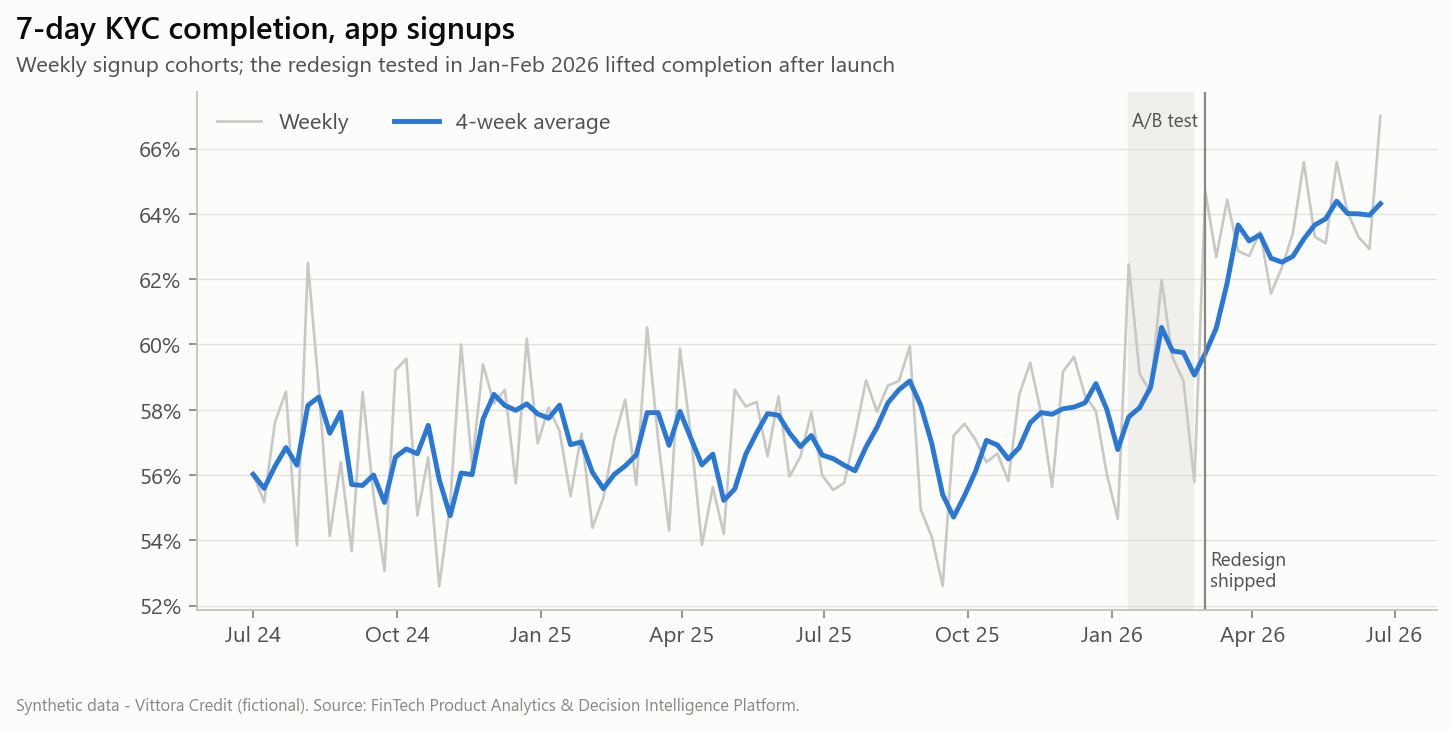

In [5]:
from IPython.display import Image
Image(filename=str(S.images_dir/'kyc_weekly_trend.png'))

## Cohort retention (monthly active)

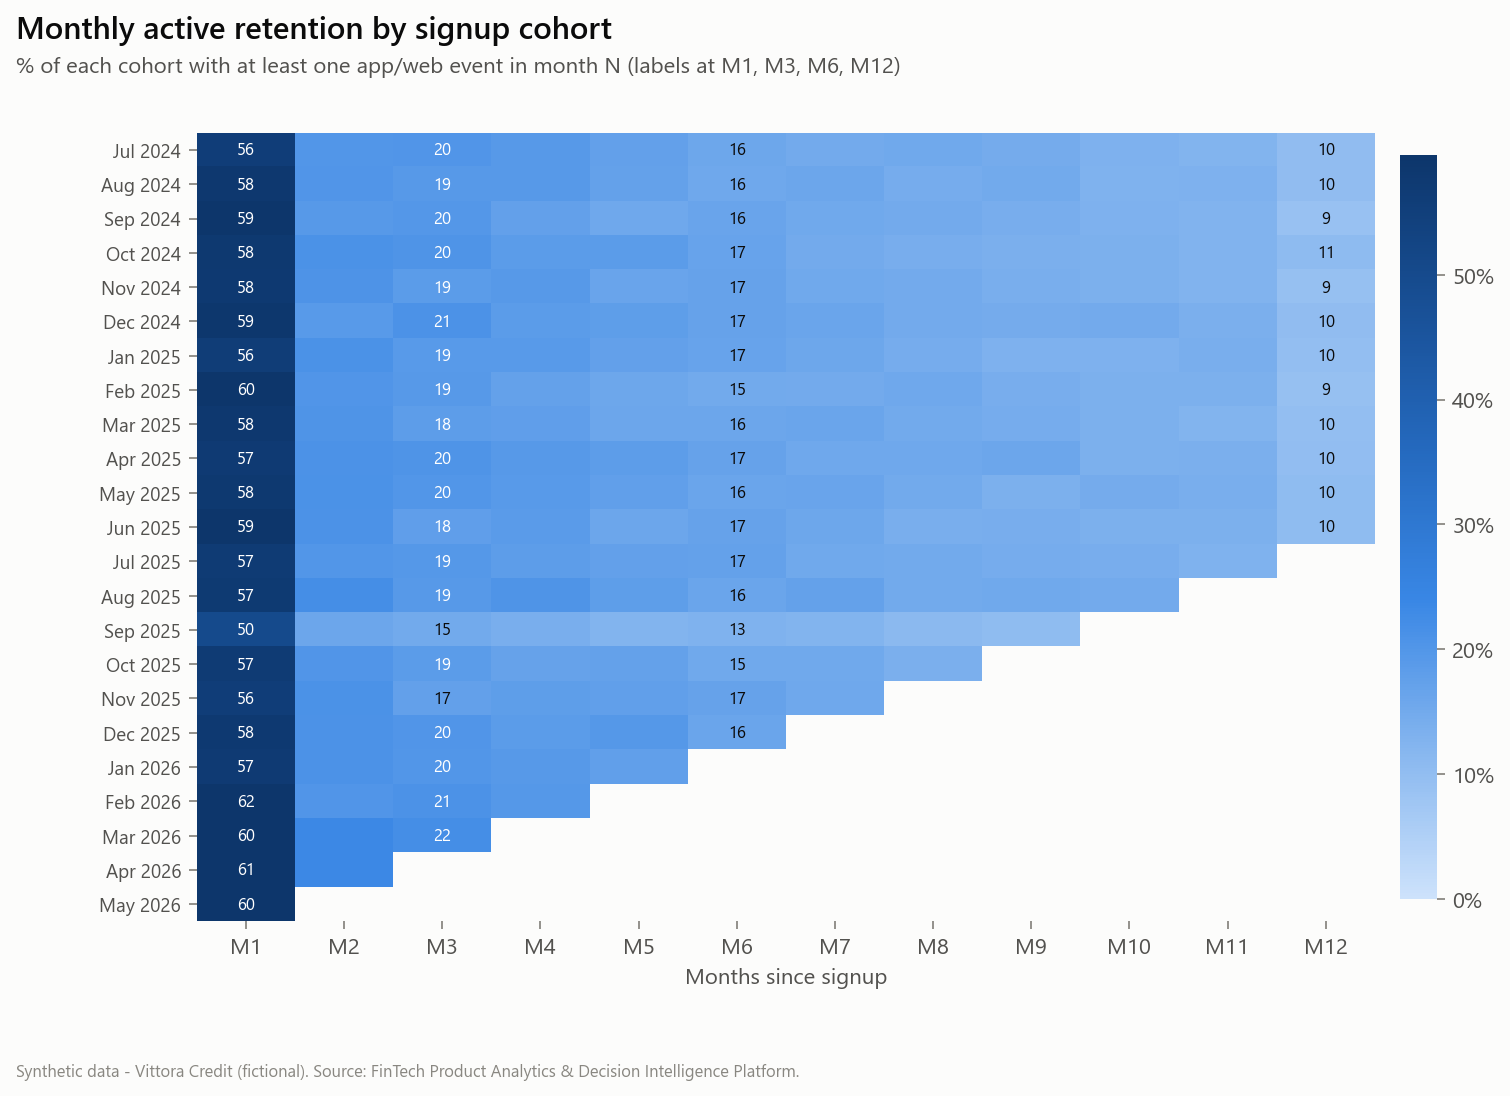

In [6]:
Image(filename=str(S.images_dir/'cohort_retention.png'))

In [7]:
pd.read_csv(S.outputs_dir/'sql_results'/'03_cohort_retention__retention_curve_by_borrower_status.csv').pivot(index='month_number', columns='borrower_status', values='retention_pct').head(13)

borrower_status,borrower,non_borrower
month_number,,
0,100.00,100.00
1,89.50,50.99
2,77.74,8.52
3,74.10,7.79
4,70.11,7.53
5,64.79,7.15
6,60.71,6.91
7,57.62,6.73
8,52.34,6.63


## Growth accounting: is MAU growth acquisition or retention?

In [8]:
pd.read_csv(S.outputs_dir/'sql_results'/'04_active_users__mau_growth_accounting.csv').tail(8)

,activity_month,mau,new_users,retained_users,resurrected_users,churned_users,month_over_month_retention_pct,quick_ratio,mau_mom_growth_pct
16,2025-11-01,12870,4276.0,6544.0,2050.0,6466.0,50.30,0.98,-1.08
17,2025-12-01,12741,3847.0,6451.0,2443.0,6419.0,50.12,0.98,-1.00
18,2026-01-01,12841,3769.0,6595.0,2477.0,6146.0,51.76,1.02,0.78
19,2026-02-01,12504,3627.0,6422.0,2455.0,6419.0,50.01,0.95,-2.62
20,2026-03-01,13712,4090.0,6758.0,2864.0,5746.0,54.05,1.21,9.66
21,2026-04-01,13898,3973.0,7218.0,2707.0,6494.0,52.64,1.03,1.36
22,2026-05-01,14705,4158.0,7476.0,3071.0,6422.0,53.79,1.13,5.81
23,2026-06-01,14918,4256.0,7795.0,2867.0,6910.0,53.01,1.03,1.45


**Takeaways:** (1) KYC is the main leak and is concentrated in web, tier-3, gig-worker and paid-social signups; (2) borrowing is what keeps users active - non-borrowers churn within two months; (3) the redesigned onboarding lifted the weekly KYC trend after launch.